In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
from sklearn.model_selection import train_test_split

data_dir = "/content/drive/MyDrive/Sheep_Classes_All_Compressed"

label_map = {
    "Standing": "standing",
    "Sitting":  "sitting",
    "Running":  "running",
    "Grazing":  "grazing",
    "Walking":  "walking"
}

records = []
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if not os.path.isdir(class_path): continue
    if class_name not in label_map: continue
    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        if os.path.isfile(fpath) and fname.lower().endswith('.mp4'):
            records.append({
                "filepath":   fpath,
                "filename":   fname,
                "class_name": class_name
            })

df = pd.DataFrame(records)
df["class_label"] = df["class_name"].map(label_map)
class_order = sorted(df["class_label"].unique())
class_to_id = {label: i for i, label in enumerate(class_order)}
df["class_id"] = df["class_label"].map(class_to_id)

print("Total videos:", len(df))
print(df["class_label"].value_counts())

train_df, test_df = train_test_split(
    df, test_size=0.20,
    stratify=df["class_label"],
    random_state=42
)
train_df["split"] = "train"
test_df["split"]  = "test"

output_dir = os.path.join(data_dir, "splits_80_20_no_extra")
os.makedirs(output_dir, exist_ok=True)
train_df.to_csv(os.path.join(output_dir, "train.csv"), index=False)
test_df.to_csv(os.path.join(output_dir,  "test.csv"),  index=False)

print(f"\nTrain: {len(train_df)} | Test: {len(test_df)}")
print("✅ CSV files saved!")

Mounted at /content/drive
Total videos: 409
class_label
standing    110
sitting      99
grazing      90
running      63
walking      47
Name: count, dtype: int64

Train: 327 | Test: 82
✅ CSV files saved!


In [ ]:
!pip install -q opencv-python-headless

import os
import re
import cv2
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

IMAGE_SIZE   = 112
CLIP_LEN     = 8
BATCH_SIZE   = 8
NUM_EPOCHS   = 10
LR           = 1e-4
NUM_WORKERS  = 2
RANDOM_STATE = 42

COMPRESSED_ROOT = "/content/drive/MyDrive/Sheep_Classes_All_Compressed"
SPLIT_DIR       = os.path.join(COMPRESSED_ROOT, "splits_80_20_no_extra")
OUTPUT_DIR_3D   = "/content/drive/MyDrive/Sheep_3D_CNN_outputs"
OUTPUT_DIR_LSTM = "/content/drive/MyDrive/Sheep_CNN_LSTM_outputs"

os.makedirs(OUTPUT_DIR_3D,   exist_ok=True)
os.makedirs(OUTPUT_DIR_LSTM, exist_ok=True)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [ ]:
train_df = pd.read_csv(os.path.join(SPLIT_DIR, "train.csv"))
test_df  = pd.read_csv(os.path.join(SPLIT_DIR, "test.csv"))

CLASS_NAMES = sorted(train_df["class_label"].unique().tolist())
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

print("Class names:", CLASS_NAMES)
print("Train videos:", len(train_df))
print("Test videos: ", len(test_df))
print("\nVideos per class (train):")
print(train_df["class_label"].value_counts().to_string())

Class names: ['grazing', 'running', 'sitting', 'standing', 'walking']
Train videos: 327
Test videos:  82

Videos per class (train):
class_label
standing    88
sitting     79
grazing     72
running     50
walking     38


In [ ]:
class_counts = [train_df[train_df["class_label"] == c].shape[0] for c in CLASS_NAMES]
class_counts_tensor = torch.tensor(class_counts, dtype=torch.float32)
class_weights = class_counts_tensor.sum() / (NUM_CLASSES * class_counts_tensor)
class_weights = class_weights.to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [72, 50, 79, 88, 38]
Class weights: tensor([0.9083, 1.3080, 0.8278, 0.7432, 1.7211], device='cuda:0')


In [ ]:
def extract_clip(video_path, clip_len=CLIP_LEN, size=IMAGE_SIZE):
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    start = random.randint(0, max(0, total - clip_len))
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)

    frames = []
    for _ in range(clip_len):
        ok, frame = cap.read()
        if ok:
            frame = cv2.resize(frame, (size, size))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        elif frames:
            frames.append(frames[-1])
    cap.release()

    while len(frames) < clip_len:
        frames.append(np.zeros((size, size, 3), dtype=np.uint8))

    return np.stack(frames)


normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

frame_transform_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    normalize
])

frame_transform_test = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    normalize
])

print("Clip extraction and transforms ready.")
print(f"Clip length: {CLIP_LEN} frames | Frame size: {IMAGE_SIZE}x{IMAGE_SIZE}")

Clip extraction and transforms ready.
Clip length: 8 frames | Frame size: 112x112


In [ ]:
class ClipDataset(Dataset):
    def __init__(self, dataframe, augment=False):
        self.records = dataframe.reset_index(drop=True)
        self.tf      = frame_transform_train if augment else frame_transform_test

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row      = self.records.iloc[idx]
        label    = CLASS_TO_ID[row["class_label"]]
        raw_clip = extract_clip(row["filepath"])
        frames   = [self.tf(raw_clip[t]) for t in range(CLIP_LEN)]
        clip_tensor = torch.stack(frames, dim=1)        # (3, T, H, W)
        return clip_tensor, label


train_ds_3d = ClipDataset(train_df, augment=True)
test_ds_3d  = ClipDataset(test_df,  augment=False)

train_loader_3d = DataLoader(train_ds_3d, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
test_loader_3d  = DataLoader(test_ds_3d,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("3D CNN Dataset:")
print(f"  Train clips: {len(train_ds_3d)}")
print(f"  Test clips : {len(test_ds_3d)}")

3D CNN Dataset:
  Train clips: 327
  Test clips : 82


In [ ]:
class CNN3D(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(3,  32,  kernel_size=3, padding=1), nn.BatchNorm3d(32),  nn.ReLU(inplace=True), nn.MaxPool3d((1,2,2)),
            nn.Conv3d(32, 64,  kernel_size=3, padding=1), nn.BatchNorm3d(64),  nn.ReLU(inplace=True), nn.MaxPool3d((2,2,2)),
            nn.Conv3d(64, 128, kernel_size=3, padding=1), nn.BatchNorm3d(128), nn.ReLU(inplace=True), nn.AdaptiveAvgPool3d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model_3d = CNN3D().to(device)
print(f"3D CNN parameters: {sum(p.numel() for p in model_3d.parameters()):,}")

with torch.no_grad():
    dummy = torch.randn(2, 3, CLIP_LEN, IMAGE_SIZE, IMAGE_SIZE).to(device)
    print(f"Output shape: {model_3d(dummy).shape}   (expected: [2, {NUM_CLASSES}])")

3D CNN parameters: 280,389
Output shape: torch.Size([2, 5])   (expected: [2, 5])


In [ ]:
criterion_3d = nn.CrossEntropyLoss(weight=class_weights)
optimizer_3d = optim.Adam(model_3d.parameters(), lr=LR, weight_decay=1e-4)
scheduler_3d = optim.lr_scheduler.StepLR(optimizer_3d, step_size=5, gamma=0.5)

history_3d      = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc_3d = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    model_3d.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for clips, labels in train_loader_3d:
        clips, labels = clips.to(device), labels.to(device)
        optimizer_3d.zero_grad()
        out  = model_3d(clips)
        loss = criterion_3d(out, labels)
        loss.backward()
        optimizer_3d.step()
        tr_loss    += loss.item() * labels.size(0)
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_total   += labels.size(0)

    model_3d.eval()
    vl_loss, vl_correct, vl_total = 0.0, 0, 0
    with torch.no_grad():
        for clips, labels in test_loader_3d:
            clips, labels = clips.to(device), labels.to(device)
            out   = model_3d(clips)
            loss  = criterion_3d(out, labels)
            vl_loss    += loss.item() * labels.size(0)
            vl_correct += (out.argmax(1) == labels).sum().item()
            vl_total   += labels.size(0)

    scheduler_3d.step()
    tr_a = tr_correct / tr_total
    vl_a = vl_correct / vl_total
    history_3d["epoch"].append(epoch)
    history_3d["train_loss"].append(tr_loss / tr_total)
    history_3d["train_acc"].append(tr_a)
    history_3d["val_loss"].append(vl_loss / vl_total)
    history_3d["val_acc"].append(vl_a)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS}  "
          f"train_loss: {tr_loss/tr_total:.4f}  train_acc: {tr_a:.4f}  "
          f"val_loss: {vl_loss/vl_total:.4f}  val_acc: {vl_a:.4f}")

    if vl_a > best_val_acc_3d:
        best_val_acc_3d = vl_a
        torch.save(model_3d.state_dict(), os.path.join(OUTPUT_DIR_3D, "3d_cnn_best.pth"))
        print(f"         --> Best model saved (val_acc={best_val_acc_3d:.4f})")

pd.DataFrame(history_3d).to_csv(os.path.join(OUTPUT_DIR_3D, "training_history.csv"), index=False)
print(f"\n3D CNN training complete. Best val acc: {best_val_acc_3d:.4f}")

Epoch  1/10  train_loss: 1.4285  train_acc: 0.3639  val_loss: 1.2487  val_acc: 0.4634
         --> Best model saved (val_acc=0.4634)
Epoch  2/10  train_loss: 1.2106  train_acc: 0.5138  val_loss: 1.1637  val_acc: 0.5000
         --> Best model saved (val_acc=0.5000)
Epoch  3/10  train_loss: 1.0989  train_acc: 0.5933  val_loss: 1.0597  val_acc: 0.6341
         --> Best model saved (val_acc=0.6341)
Epoch  4/10  train_loss: 1.1303  train_acc: 0.5657  val_loss: 1.0619  val_acc: 0.5610
Epoch  5/10  train_loss: 1.0339  train_acc: 0.6361  val_loss: 0.9716  val_acc: 0.6707
         --> Best model saved (val_acc=0.6707)
Epoch  6/10  train_loss: 1.0194  train_acc: 0.6177  val_loss: 0.9663  val_acc: 0.6098
Epoch  7/10  train_loss: 1.0667  train_acc: 0.6300  val_loss: 0.9044  val_acc: 0.6707
Epoch  8/10  train_loss: 0.9985  train_acc: 0.6300  val_loss: 0.9312  val_acc: 0.6829
         --> Best model saved (val_acc=0.6829)
Epoch  9/10  train_loss: 0.9428  train_acc: 0.6850  val_loss: 0.9391  val_acc

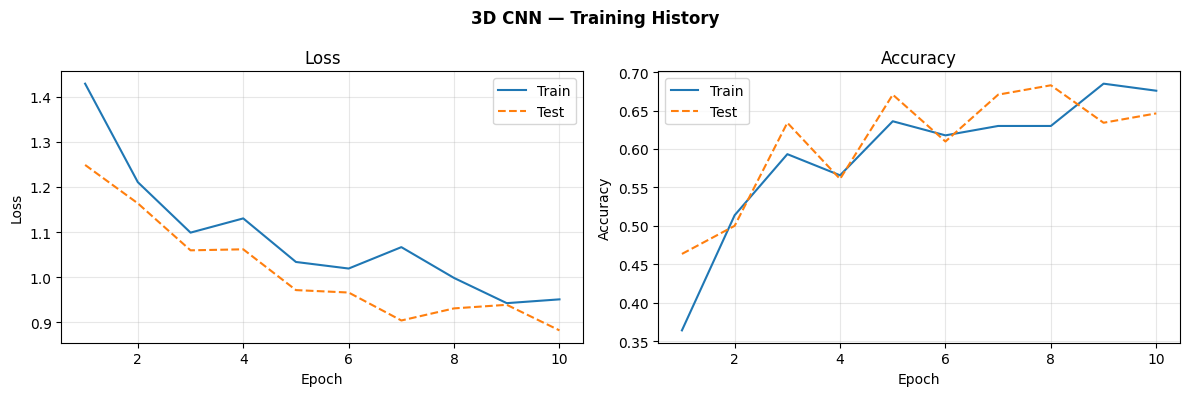

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("3D CNN — Training History", fontweight="bold")

ax1.plot(history_3d["epoch"], history_3d["train_loss"], label="Train")
ax1.plot(history_3d["epoch"], history_3d["val_loss"],   label="Test", linestyle="--")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_title("Loss")

ax2.plot(history_3d["epoch"], history_3d["train_acc"], label="Train")
ax2.plot(history_3d["epoch"], history_3d["val_acc"],   label="Test", linestyle="--")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend(); ax2.grid(alpha=0.3); ax2.set_title("Accuracy")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_3D, "training_curves.png"), dpi=150)
plt.show()

Clip-level Test Accuracy: 0.6585

Clip-level Classification Report:
              precision    recall  f1-score   support

     grazing       0.71      0.67      0.69        18
     running       0.52      0.92      0.67        13
     sitting       0.69      0.45      0.55        20
    standing       0.74      0.91      0.82        22
     walking       0.50      0.11      0.18         9

    accuracy                           0.66        82
   macro avg       0.63      0.61      0.58        82
weighted avg       0.66      0.66      0.63        82



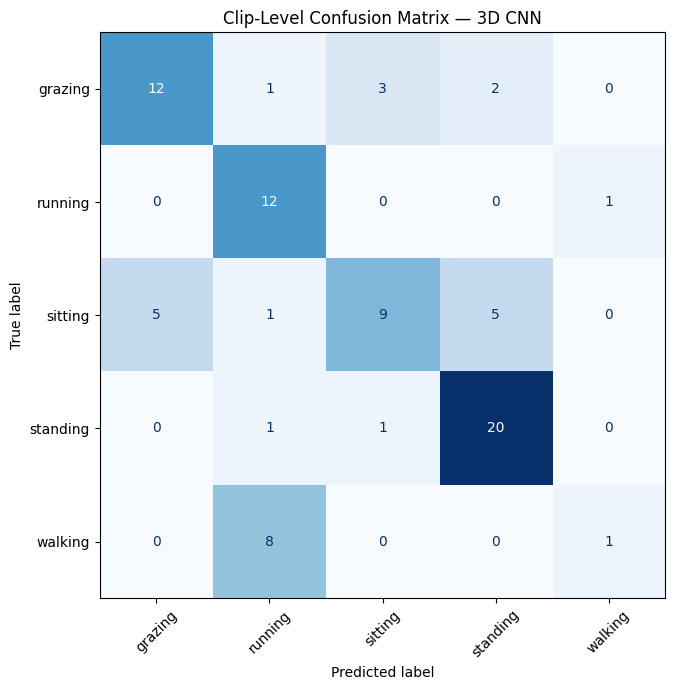

In [ ]:
model_3d.load_state_dict(torch.load(os.path.join(OUTPUT_DIR_3D, "3d_cnn_best.pth")))
model_3d.eval()

all_preds_3d  = []
all_labels_3d = []
all_probs_3d  = []
all_vids_3d   = []

with torch.no_grad():
    for i, (clips, labels) in enumerate(test_loader_3d):
        clips, labels = clips.to(device), labels.to(device)
        out   = model_3d(clips)
        probs = torch.softmax(out, dim=1)
        preds = out.argmax(1)
        all_preds_3d.extend(preds.cpu().numpy())
        all_labels_3d.extend(labels.cpu().numpy())
        all_probs_3d.extend(probs.cpu().numpy())
        batch_start = i * BATCH_SIZE
        for j in range(labels.size(0)):
            all_vids_3d.append(test_df.iloc[batch_start + j]["filepath"])

clip_acc_3d    = accuracy_score(all_labels_3d, all_preds_3d)
clip_report_3d = classification_report(all_labels_3d, all_preds_3d, target_names=CLASS_NAMES)
clip_cm_3d     = confusion_matrix(all_labels_3d, all_preds_3d)

print(f"Clip-level Test Accuracy: {clip_acc_3d:.4f}\n")
print("Clip-level Classification Report:")
print(clip_report_3d)

with open(os.path.join(OUTPUT_DIR_3D, "clip_test_metrics.txt"), "w") as f:
    f.write(f"Clip-level Test Accuracy: {clip_acc_3d:.4f}\n\n")
    f.write(clip_report_3d)

fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(confusion_matrix=clip_cm_3d, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap="Blues", colorbar=False)
plt.title("Clip-Level Confusion Matrix — 3D CNN")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_3D, "clip_confusion_matrix.png"), dpi=150)
plt.show()

Video-level Test Accuracy: 0.6585

Video-level Classification Report:
              precision    recall  f1-score   support

     grazing       0.71      0.67      0.69        18
     running       0.52      0.92      0.67        13
     sitting       0.69      0.45      0.55        20
    standing       0.74      0.91      0.82        22
     walking       0.50      0.11      0.18         9

    accuracy                           0.66        82
   macro avg       0.63      0.61      0.58        82
weighted avg       0.66      0.66      0.63        82



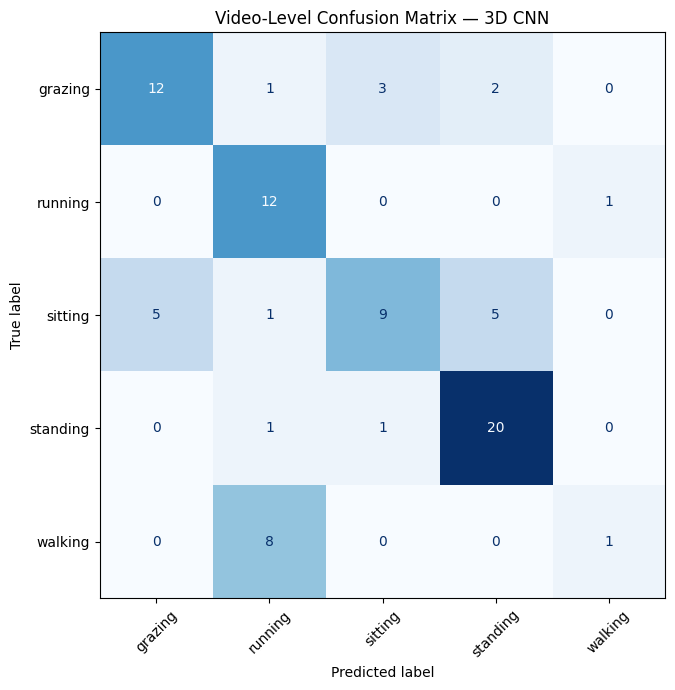

In [ ]:
def get_video_id(filepath):
    name = os.path.splitext(os.path.basename(filepath))[0]
    return re.sub(r"_compressed$", "", name)

pred_df_3d = pd.DataFrame({
    "filepath":        all_vids_3d,
    "true_label_id":   all_labels_3d,
    "pred_label_id":   all_preds_3d,
    "true_label_name": [CLASS_NAMES[i] for i in all_labels_3d],
    "pred_label_name": [CLASS_NAMES[i] for i in all_preds_3d],
})

prob_array_3d = np.array(all_probs_3d)
prob_cols     = [f"prob_{c}" for c in CLASS_NAMES]
for i, c in enumerate(CLASS_NAMES):
    pred_df_3d[f"prob_{c}"] = prob_array_3d[:, i]

pred_df_3d["video_id"] = pred_df_3d["filepath"].apply(get_video_id)

video_df_3d = pred_df_3d.groupby("video_id").agg(
    true_label_id=("true_label_id", "first"),
    true_label_name=("true_label_name", "first"),
    **{col: (col, "mean") for col in prob_cols}
).reset_index()

video_df_3d["pred_label_id"]   = video_df_3d[prob_cols].values.argmax(axis=1)
video_df_3d["pred_label_name"] = video_df_3d["pred_label_id"].apply(lambda x: CLASS_NAMES[x])

video_true_3d = video_df_3d["true_label_id"].tolist()
video_pred_3d = video_df_3d["pred_label_id"].tolist()

video_acc_3d    = accuracy_score(video_true_3d, video_pred_3d)
video_report_3d = classification_report(video_true_3d, video_pred_3d, target_names=CLASS_NAMES)
video_cm_3d     = confusion_matrix(video_true_3d, video_pred_3d)

print(f"Video-level Test Accuracy: {video_acc_3d:.4f}\n")
print("Video-level Classification Report:")
print(video_report_3d)

with open(os.path.join(OUTPUT_DIR_3D, "video_test_metrics.txt"), "w") as f:
    f.write(f"Video-level Test Accuracy: {video_acc_3d:.4f}\n\n")
    f.write(video_report_3d)

video_df_3d.to_csv(os.path.join(OUTPUT_DIR_3D, "video_test_predictions.csv"), index=False)

fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(confusion_matrix=video_cm_3d, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap="Blues", colorbar=False)
plt.title("Video-Level Confusion Matrix — 3D CNN")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_3D, "video_confusion_matrix.png"), dpi=150)
plt.show()